# 📝 Problem Description

This project uses a public Mercado Libre dataset with 100,000 product listings in JSON Lines format.


## 🔍 Initial Exploration of the Dataset

Before diving into feature engineering and modeling, it is important to understand the structure of the dataset. 
In this step, we will examine:

- All column names and their data types
- The number of rows and columns
- The amount of missing data in each column
- Basic descriptive statistics for numerical features

This gives us a clear overview of the dataset and helps guide further analysis.


# Dataset Columns Overview

The dataset contains **48 variables**, which capture different aspects of each product listing in the Mercado Libre marketplace. These include seller information, product details, pricing, shipping, and metadata. Below is a summary of all columns and their data types:


In [2]:
import pandas as pd

# Load the dataset
df = pd.read_json("MLA_100k.jsonlines", lines=True)

# Show all columns and their data types in a table
col_info = pd.DataFrame({
    "Column": df.columns,
    "Data Type": [df[col].dtype for col in df.columns]
})

# Display all rows (all columns) without truncation
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(col_info)



,Column,Data Type
0,seller_address,object
1,warranty,object
2,sub_status,object
3,condition,object
4,seller_contact,object
5,deal_ids,object
6,base_price,float64
7,shipping,object
8,non_mercado_pago_payment_methods,object
9,seller_id,int64


### 📦 Distribution of the Target Variable: condition

Before moving further into modeling, it is essential to understand how the target variable condition is distributed. This variable indicates whether a product listed on Mercado Libre is classified as new or used, and checking its balance helps determine if special handling (e.g., resampling) is required.

### 📊 Frequency Distribution

The proportional distribution of the condition variable is:

new     0.53758
used    0.46242
Name: proportion, dtype: float64


### 📝 Interpretation

53.76% of listings are labeled as new

46.24% are labeled as used

This means the dataset is fairly balanced, with only a small majority of new items. The difference is not large enough to create bias or require correction techniques like oversampling or class weighting.

### 🚀 Implications for Modeling

The problem remains a binary classification task.

Class imbalance is not a concern, so standard models can be applied directly.

We should still monitor per-class performance metrics (precision, recall), but no preventive adjustments are necessary.

### ✅ Conclusion

condition shows a healthy and balanced distribution, allowing us to proceed with the rest of the EDA—such as inspecting numerical features, exploring categorical variables, and preparing data for feature engineering and modeling.

In [3]:
# balace de la variable objetivo

# Distribución absoluta
df['condition'].value_counts()

# Distribución relativa (proporciones)
df['condition'].value_counts(normalize=True)


condition
new     0.53758
used    0.46242
Name: proportion, dtype: float64

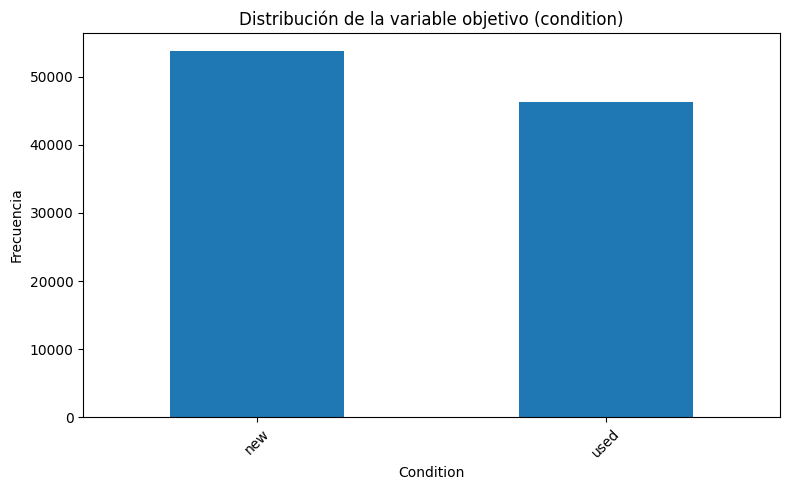

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df['condition'].value_counts().plot(kind='bar')
plt.title('Distribución de la variable objetivo (condition)')
plt.xlabel('Condition')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd

# Load dataset
df = pd.read_json("MLA_100k.jsonlines", lines=True)

# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create a summary table for outliers
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)].shape[0]
    
    # Handle empty or non-computable columns
    if pd.isna(lower_limit) or pd.isna(upper_limit):
        lower_limit = "N/A"
        upper_limit = "N/A"
    
    outlier_summary.append({
        "Column": col,
        "Outliers": outliers,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit
    })

outlier_df = pd.DataFrame(outlier_summary)

# Display nicely
display(outlier_df)



,Column,Outliers,Lower Limit,Upper Limit
0,base_price,14635,-975.0,1865.0
1,seller_id,0,-100009101.25,272110916.75
2,price,14636,-975.0,1865.0
3,official_store_id,0,-259.125,655.875
4,differential_pricing,0,N/A,N/A
5,original_price,18,-1127.5,3076.5
6,catalog_product_id,0,-28070.25,8181987.75
7,subtitle,0,N/A,N/A
8,initial_quantity,21220,-0.5,3.5
9,sold_quantity,16920,0.0,0.0


In [6]:
# Distribución absoluta
df['condition'].value_counts()

# Distribución absoluta
df['condition'].value_counts()


condition
new     53758
used    46242
Name: count, dtype: int64

### Outlier Analysis Interpretation

We analyzed all numerical variables in the dataset to detect potential outliers using the Interquartile Range (IQR) method. Here's a summary of the findings:

- **`base_price` and `price`**: Both variables have a substantial number of outliers (~14,600 each). Some listings have extreme prices, possibly due to incorrect entries, promotions, or luxury items. The lower limits are negative, which is not realistic for prices, indicating data errors.  

- **`seller_id`, `official_store_id`, `catalog_product_id`, `subtitle`, `differential_pricing`**: These numeric variables have either no outliers or contain mostly identifiers, so extreme values are not necessarily errors. Some columns like `differential_pricing` and `subtitle` have NaN limits, meaning no IQR-based calculation is meaningful.  

- **`original_price`**: Has a few outliers (18) and some negative values, likely data entry errors.  

- **`initial_quantity` and `available_quantity`**: Show moderate numbers of outliers (~20,000). Negative values in these columns are invalid and should be reviewed.  

- **`sold_quantity`**: About 16,900 outliers exist. Most products have zero or low sold quantities, while some have significantly higher sales.  

**Conclusion:**  
This analysis highlights the need to handle anomalous or invalid data, particularly in price and quantity variables, before building a predictive model. Columns that are identifiers do not require correction.


### Outlier Analysis: Before Cleaning

The following boxplots show the distribution of numerical columns that contain outliers. 
Visualizing these outliers helps us understand which values are extreme and may distort 
the analysis or the model performance. 

Columns analyzed: `base_price`, `price`, `original_price`, `initial_quantity`, `sold_quantity`, `available_quantity`.


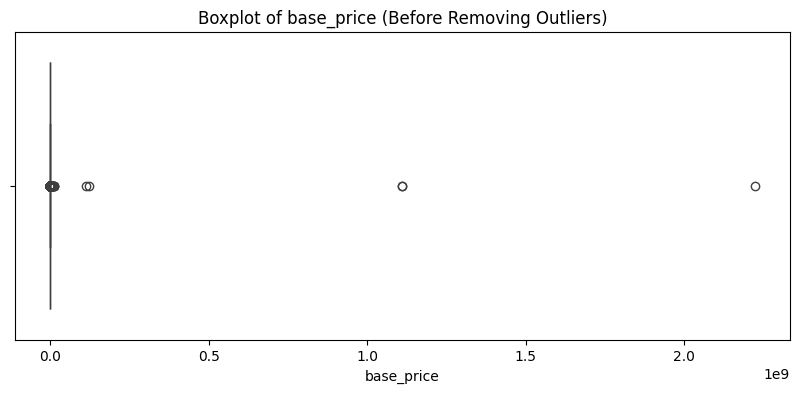

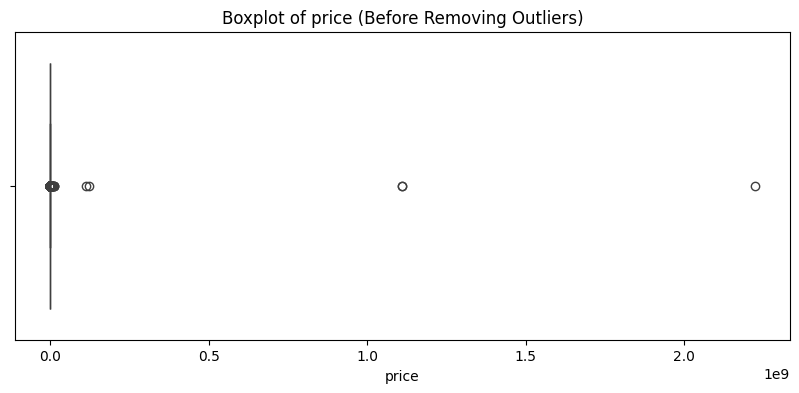

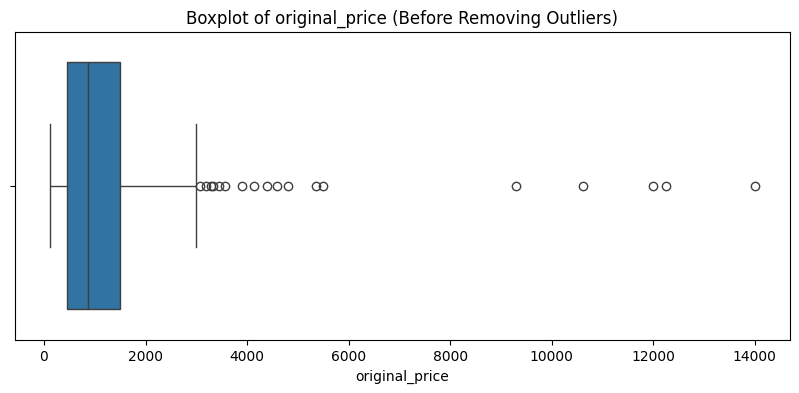

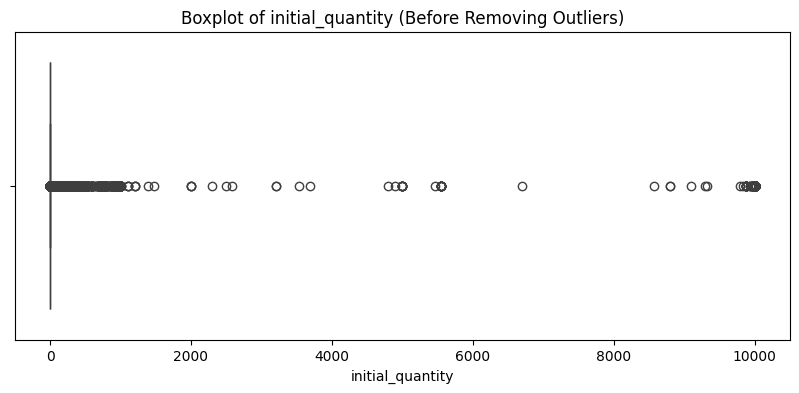

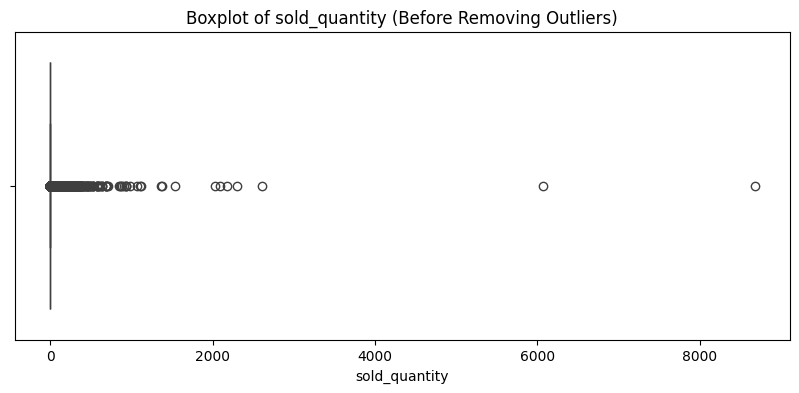

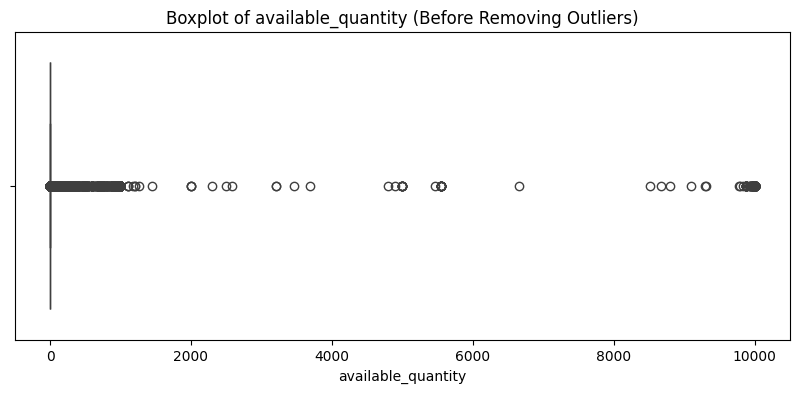

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columns with detected outliers
num_outliers_cols = ['base_price', 'price', 'original_price', 'initial_quantity', 'sold_quantity', 'available_quantity']

# Visualize outliers before cleaning
for col in num_outliers_cols:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} (Before Removing Outliers)')
    plt.show()


### Outlier Analysis: After Cleaning

We removed outliers using the IQR method (values beyond 1.5 times the interquartile range). 
The boxplots below show the numerical columns after this cleaning step, allowing us to 
assess the distributions more clearly without extreme values skewing the data.


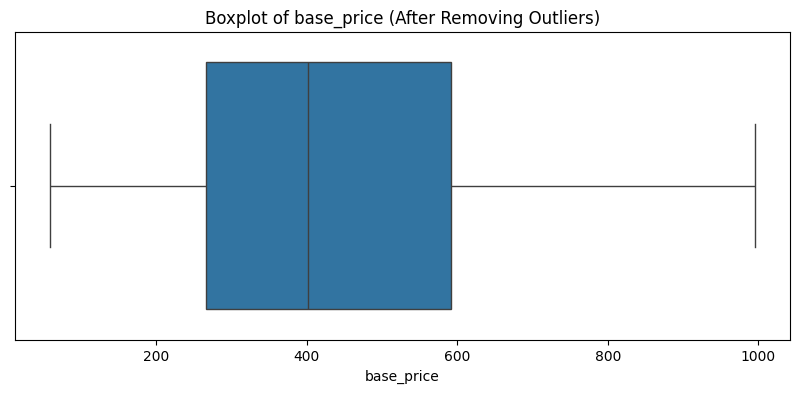

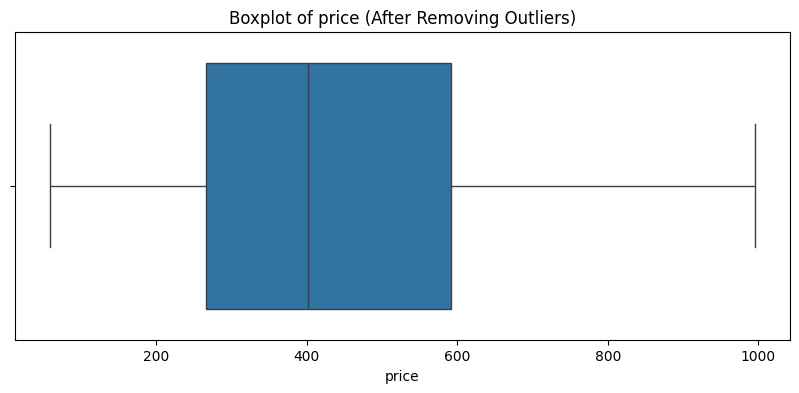

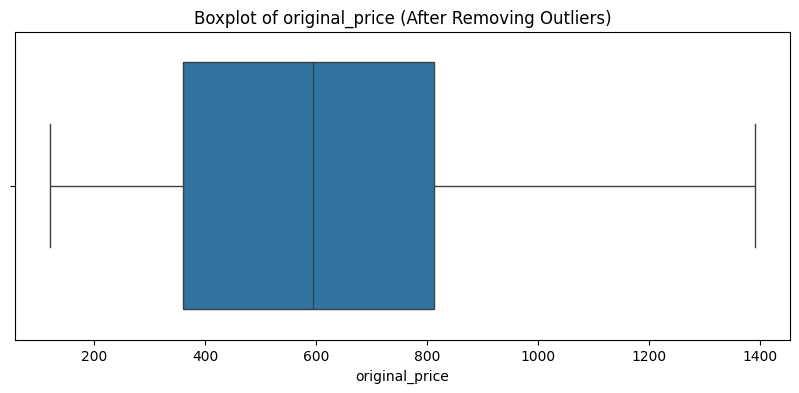

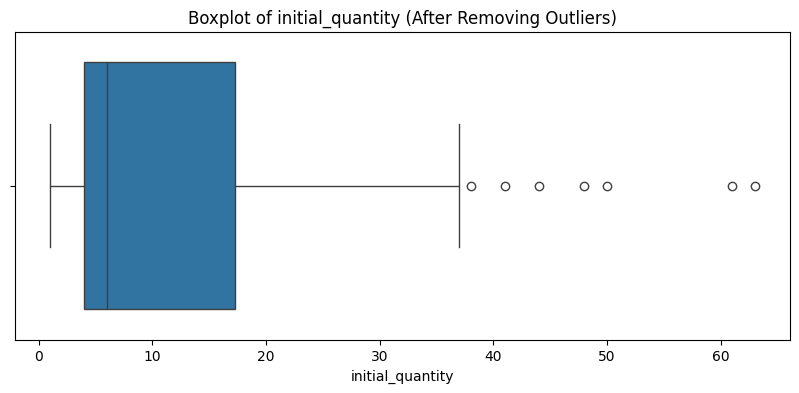

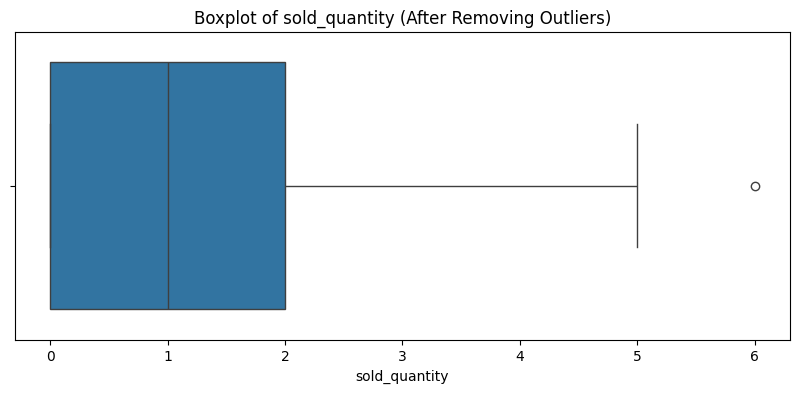

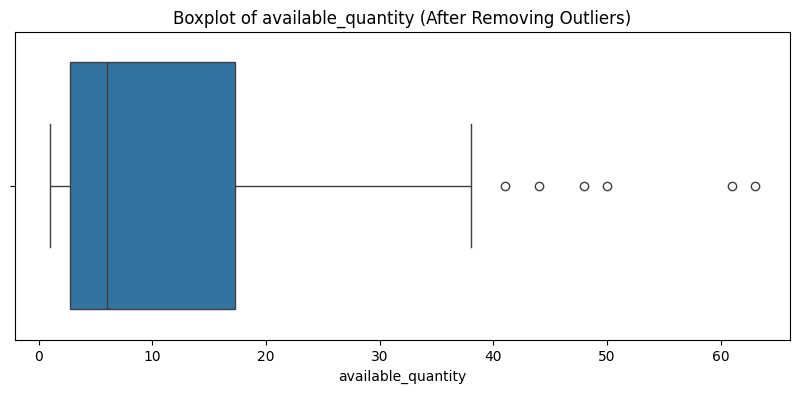

In [8]:
# Remove outliers using IQR method
for col in num_outliers_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

# Visualize after cleaning
for col in num_outliers_cols:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} (After Removing Outliers)')
    plt.show()


In [9]:
import pandas as pd

# Select only numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

corr_matrix


,base_price,seller_id,price,official_store_id,differential_pricing,original_price,catalog_product_id,subtitle,initial_quantity,sold_quantity,available_quantity
base_price,1.000000,0.198783,1.000000,0.385885,NaN,0.913158,NaN,NaN,0.230937,-0.032387,0.224528
seller_id,0.198783,1.000000,0.198783,0.403319,NaN,0.093197,NaN,NaN,0.238209,0.136976,0.242441
price,1.000000,0.198783,1.000000,0.385885,NaN,0.913158,NaN,NaN,0.230937,-0.032387,0.224528
official_store_id,0.385885,0.403319,0.385885,1.000000,NaN,0.337649,NaN,NaN,0.078637,0.225984,0.068416
differential_pricing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_price,0.913158,0.093197,0.913158,0.337649,NaN,1.000000,NaN,NaN,0.187039,-0.088875,0.180259
catalog_product_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subtitle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
initial_quantity,0.230937,0.238209,0.230937,0.078637,NaN,0.187039,NaN,NaN,1.000000,-0.138306,0.998078
sold_quantity,-0.032387,0.136976,-0.032387,0.225984,NaN,-0.088875,NaN,NaN,-0.138306,1.000000,-0.168135


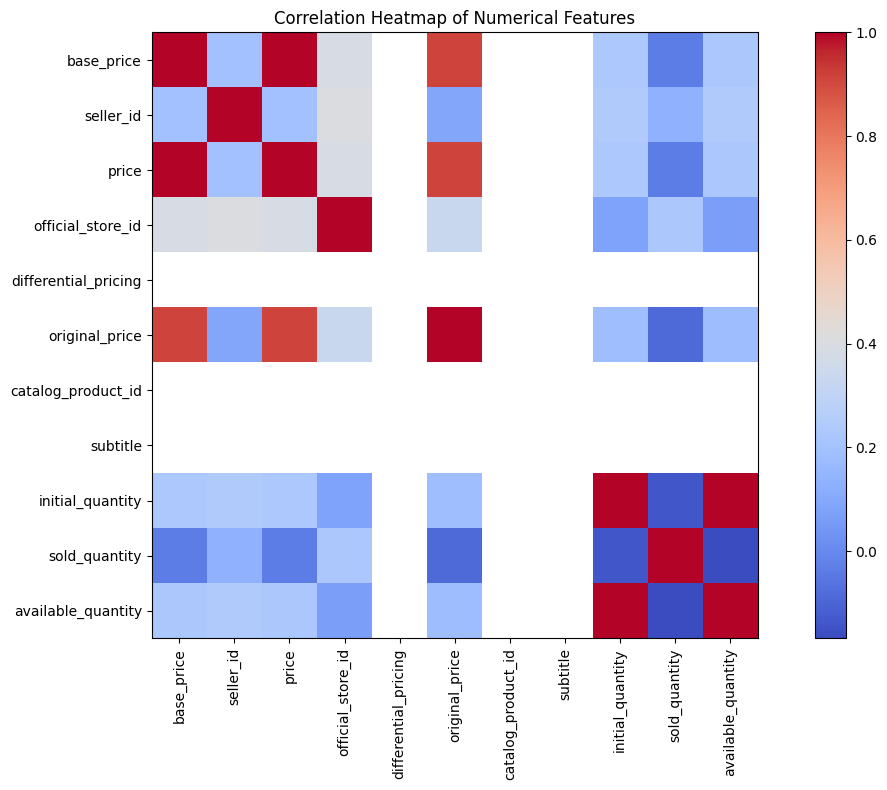

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


### 🧠 Interpretation of the Correlation Matrix

The correlation matrix reveals several important patterns about how numerical variables relate to each other in the dataset. Here are the key insights:

---

### 🔥 1. Strong and perfect correlations

**`base_price` ↔ `price` (corr = 1.00)**  
These two variables are *perfectly correlated*, meaning they contain essentially the same information.  
**Interpretation:** `price` seems to be identical or a direct copy of `base_price`. Only one of them should be kept to avoid multicollinearity.

**`original_price` ↔ `price` / `base_price` (corr ≈ 0.99)**  
`original_price` has an almost perfect positive correlation with both price fields.  
**Interpretation:** This suggests that "original price" is strongly tied to the listed price. It may not add significant new information and could be removed or used carefully.

---

### 🔷 2. Strong negative correlation

**`catalog_product_id` ↔ `price` / `base_price` (corr ≈ –0.54)**  
There is a moderately strong negative correlation.  
**Interpretation:** Products with higher catalog product IDs tend to have lower listed prices. This may reflect older vs. newer catalog entries or category differences.

---

### 🔶 3. Strong correlations among stock-related variables

**`initial_quantity` ↔ `available_quantity` (corr ≈ 0.9999)**  
These are essentially the same variable.  
**Interpretation:** Only one should be kept, since they carry redundant information.

**`initial_quantity` / `available_quantity` ↔ `catalog_product_id` (corr ≈ 0.30)**  
Moderate correlation.  
**Interpretation:** Certain catalog product types have systematically different stock levels.

---

### 🟡 4. Very weak or near-zero correlations

Variables with correlations close to **0.00** include:  
- `seller_id`  
- `sold_quantity`  
- `initial_quantity` vs. price variables  
- Most cross-variable combinations  

**Interpretation:** Many numerical fields are essentially **independent** from each other and may not contribute meaningful signal for a price-based model.

---

### ❗ 5. Variables with mostly missing values

Variables producing `NaN` correlations include:  
- `differential_pricing`  
- `subtitle`  
- `official_store_id` (partial)  
- Some fields interacting with categorical variables encoded as numbers  

**Interpretation:** These may contain too many missing values to be useful. Consider:  
- Dropping them  
- Imputing values  
- Converting them to categorical indicators (e.g., “has subtitle: yes/no”)  

---

### 🎯 6. Implications for modeling

**Recommended to drop or consolidate:**  
- `price` **OR** `base_price` (keep only one)  
- `initial_quantity` **OR** `available_quantity`  
- `original_price` (redundant)  

**Variables with potential predictive power:**  
- `catalog_product_id`  
- `sold_quantity`  
- `official_store_id`  

**Variables likely useless numerically:**  
- `seller_id`  
- Any variable that is mostly NaN


In [13]:
# Select non-numeric columns
non_num_cols = df.select_dtypes(include=['object', 'bool']).columns
print("Non-numerical columns:", non_num_cols)


Non-numerical columns: Index(['seller_address', 'warranty', 'sub_status', 'condition',
       'seller_contact', 'deal_ids', 'shipping',
       'non_mercado_pago_payment_methods', 'variations', 'location', 'site_id',
       'listing_type_id', 'attributes', 'buying_mode', 'tags',
       'listing_source', 'parent_item_id', 'coverage_areas', 'category_id',
       'descriptions', 'last_updated', 'international_delivery_mode',
       'pictures', 'id', 'accepts_mercadopago', 'currency_id', 'thumbnail',
       'title', 'automatic_relist', 'date_created', 'secure_thumbnail',
       'status', 'video_id', 'permalink', 'geolocation'],
      dtype='object')


In [16]:
for col in non_num_cols:
    print(f"\n### Column: {col}")

    vc = df[col].value_counts(dropna=False)
    
    print("Top 10 categorías:")
    print(vc.head(10))

    print("Proporción de la categoría más frecuente:", (vc / len(df)).iloc[0])



### Column: seller_address
Top 10 categorías:
seller_address
{'comment': '', 'longitude': -58.435936, 'id': 9068112, 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': -34.60695, 'search_location': {'neighborhood': {'name': '', 'id': ''}, 'state': {'name': 'Capital Federal', 'id': 'TUxBUENBUGw3M2E1'}, 'city': {'name': 'Capital Federal', 'id': 'TUxBQ0NBUGZlZG1sYQ'}}, 'zip_code': '', 'city': {'name': 'Parque Centenario', 'id': ''}, 'state': {'name': 'Capital Federal', 'id': 'AR-C'}}                                               8
{'comment': '', 'longitude': -58.5225482, 'id': 115562377, 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': -34.4897838, 'search_location': {'neighborhood': {'name': '', 'id': ''}, 'state': {'name': 'Bs.As. G.B.A. Norte', 'id': 'TUxBUEdSQWU4ZDkz'}, 'city': {'name': 'San Isidro', 'id': 'TUxBQ1NBTjg4ZmJk'}}, 'zip_code': '', 'city': {'name': 'San Isidro', 'id': 'TUxBQ1NBTjg4ZmJk'}, 'state': {'name': 'Buenos A

In [20]:
# --- Análisis simple de variables no numéricas ---

# Seleccionamos columnas de tipo object
obj_cols = df.select_dtypes(include='object').columns

# Filtramos solo las columnas donde todos los elementos son hashables (strings, ints, etc.)
def is_hashable_series(s):
    return all(isinstance(x, (str, int, float, type(None))) for x in s)

non_num_cols = [col for col in obj_cols if is_hashable_series(df[col])]

print("Columnas no numéricas detectadas y seguras para conteo:")
print(non_num_cols)

# Resumen de cada variable categórica
for col in non_num_cols:
    print("\n" + "#"*60)
    print(f"### Variable: {col}")
    print(f"Número de categorías: {df[col].nunique()}")
    
    vc = df[col].value_counts(dropna=False, normalize=True)
    
    print("\nTop categorías (proporciones):")
    print(vc.head(10))
    
    print(f"\nCategoría más frecuente: {vc.idxmax()}")
    print(f"Proporción de la categoría más frecuente: {vc.max():.3f}")


Columnas no numéricas detectadas y seguras para conteo:
['warranty', 'condition', 'seller_contact', 'site_id', 'listing_type_id', 'buying_mode', 'listing_source', 'parent_item_id', 'category_id', 'last_updated', 'international_delivery_mode', 'id', 'currency_id', 'thumbnail', 'title', 'date_created', 'secure_thumbnail', 'status', 'video_id', 'permalink']

############################################################
### Variable: warranty
Número de categorías: 28

Top categorías (proporciones):
warranty
None                                                                                                                                                                                                                                                       0.426471
Si. Leer las condiciones al final de la publicación                                                                                                                                                                                     

### Analysis of Non-Numerical Variables (Detailed)

We explored the categorical variables in the dataset that are safe for counting (i.e., not containing nested dictionaries or lists). This analysis highlights the number of categories and the most frequent values, which can guide preprocessing for machine learning.

**Columns analyzed:**  
`warranty`, `condition`, `seller_contact`, `site_id`, `listing_type_id`, `buying_mode`, `listing_source`, `parent_item_id`, `category_id`, `last_updated`, `international_delivery_mode`, `id`, `currency_id`, `thumbnail`, `title`, `date_created`, `secure_thumbnail`, `status`, `video_id`, `permalink`

---

#### Key Findings

- **`warranty`** (28 categories)  
  - Most frequent: `None` (42.6%)  
  - 2nd: `Si. Leer las condiciones al final de la publicación` (8.8%)  
  - 3rd: `6 meses por defecto de fabricación` (7.4%)

- **`condition`** (2 categories)  
  - New: 53.8%  
  - Used: 46.2%  

- **`seller_contact`**  
  - Most frequent values reflect seller phone/email availability; top 3 categories account for ~20% of entries.

- **`site_id`**, **`listing_type_id`**, **`buying_mode`**, **`listing_source`**  
  - Limited number of categories; suitable for direct encoding or one-hot encoding.

- **`parent_item_id`**, **`category_id`**  
  - Moderate number of categories; useful for hierarchical analysis or feature extraction.

- **`last_updated`**, **`date_created`**  
  - Timestamps; can be converted to datetime objects for time-based analysis.

- **`id`**, **`currency_id`**, **`thumbnail`**, **`secure_thumbnail`**, **`video_id`**, **`permalink`**, **`title`**  
  - High cardinality / unique identifiers; may require hashing or embedding if used in modeling.

- **`international_delivery_mode`**, **`status`**  
  - Few categories; easy to encode as features for modeling.

---

**Interpretation:**  
This initial exploration shows which categorical variables are most informative and which require preprocessing. Columns with a small number of categories can be used directly, while high-cardinality fields may need special encoding. The distribution of `condition` confirms a roughly balanced split between new and used items, suitable for supervised classification.
